# Chromosome IV Replicate 2 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

_, config = load_default_chrom_configs()
config.shift_parameters_for_alpha()

real_deconv2 = RealDataReplicationDeconvolution(config, replicate=2, chr=4)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


In [3]:
real_deconv2.config.params_dic

{'mu0': -0.1509999999999998,
 'delta': 10.8953,
 'sigma0': 10.631,
 'sigmav': 0.1297,
 'lambda': 60.2093,
 'gamma1': 0.3338745976119968,
 'gamma2': 0.6158745976119968,
 'halted': 0.2906,
 'alpha': 20}

In [4]:
real_deconv2.setup_deconvolution(real_deconv2.config)
real_deconv2.iterative_deconvolution_updates(1)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/706 - 00:00:00.004
100/706 - 00:00:00.067
200/706 - 00:00:00.112
300/706 - 00:00:00.162
400/706 - 00:00:00.210
500/706 - 00:00:00.245
600/706 - 00:00:00.291
700/706 - 00:00:00.332
Iteration completed 00:00:01.357, rn=0.004568264225287324


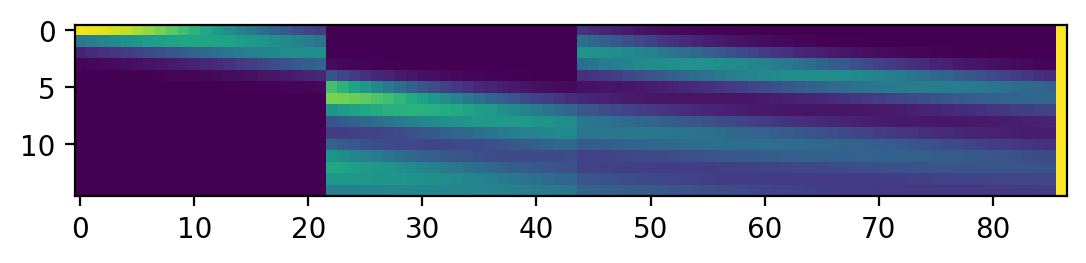

In [5]:
plt.imshow(real_deconv2.config.H, vmax=0.05)

In [6]:
from src.optimize_H import ParameterOptimizer

In [7]:
timepoints = config.timepoints
initial_values = config.params_dic

init_params_df = pd.DataFrame(initial_values, index=['value']).T
init_params_df = init_params_df.drop('alpha')
init_params_df

,value
mu0,-0.151000
delta,10.895300
sigma0,10.631000
sigmav,0.129700
lambda,60.209300
gamma1,0.333875
gamma2,0.615875
halted,0.290600


In [8]:
bounds_dic = {
    'mu0': (-30, 30),
    'lambda': (40, 80),
    'delta': (0, 14),
    'sigma0': (1, 14),
    'sigmav': (0.01, 1.),
    'gamma1': (0., 1.),
    'gamma2': (0., 1.),
    'halted': (0.0, 1.),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,-0.151000,-30.00,30.0
delta,10.895300,0.00,14.0
sigma0,10.631000,1.00,14.0
sigmav,0.129700,0.01,1.0
lambda,60.209300,60.00,80.0
gamma1,0.333875,0.00,1.0
gamma2,0.615875,0.00,1.0
halted,0.290600,0.00,1.0


In [9]:
real_deconv2.setup_deconvolution(real_deconv2.config)

Initializing N using config H.
Initializing B using timepoint 0


In [10]:
real_deconv2.iterative_deconvolution_updates(20)

Iteration 0
0/706 - 00:00:00.051
100/706 - 00:00:00.095
200/706 - 00:00:00.134
300/706 - 00:00:00.175
400/706 - 00:00:00.210
500/706 - 00:00:00.250
600/706 - 00:00:00.287
700/706 - 00:00:00.325
Iteration completed 00:00:01.624, rn=0.004568264225287324
Iteration 1
0/706 - 00:00:01.625
100/706 - 00:00:01.663
200/706 - 00:00:01.710
300/706 - 00:00:01.751
400/706 - 00:00:01.794
500/706 - 00:00:01.846
600/706 - 00:00:01.884
700/706 - 00:00:01.935
Iteration completed 00:00:03.155, rn=0.0029596766819611747
Iteration 2
0/706 - 00:00:03.157
100/706 - 00:00:03.198
200/706 - 00:00:03.245
300/706 - 00:00:03.290
400/706 - 00:00:03.327
500/706 - 00:00:03.362
600/706 - 00:00:03.398
700/706 - 00:00:03.434
Iteration completed 00:00:04.753, rn=0.002653227119847048
Iteration 3
0/706 - 00:00:04.754
100/706 - 00:00:04.789
200/706 - 00:00:04.825
300/706 - 00:00:04.860
400/706 - 00:00:04.896
500/706 - 00:00:04.931
600/706 - 00:00:04.967
700/706 - 00:00:05.004
Iteration completed 00:00:06.248, rn=0.0024840818

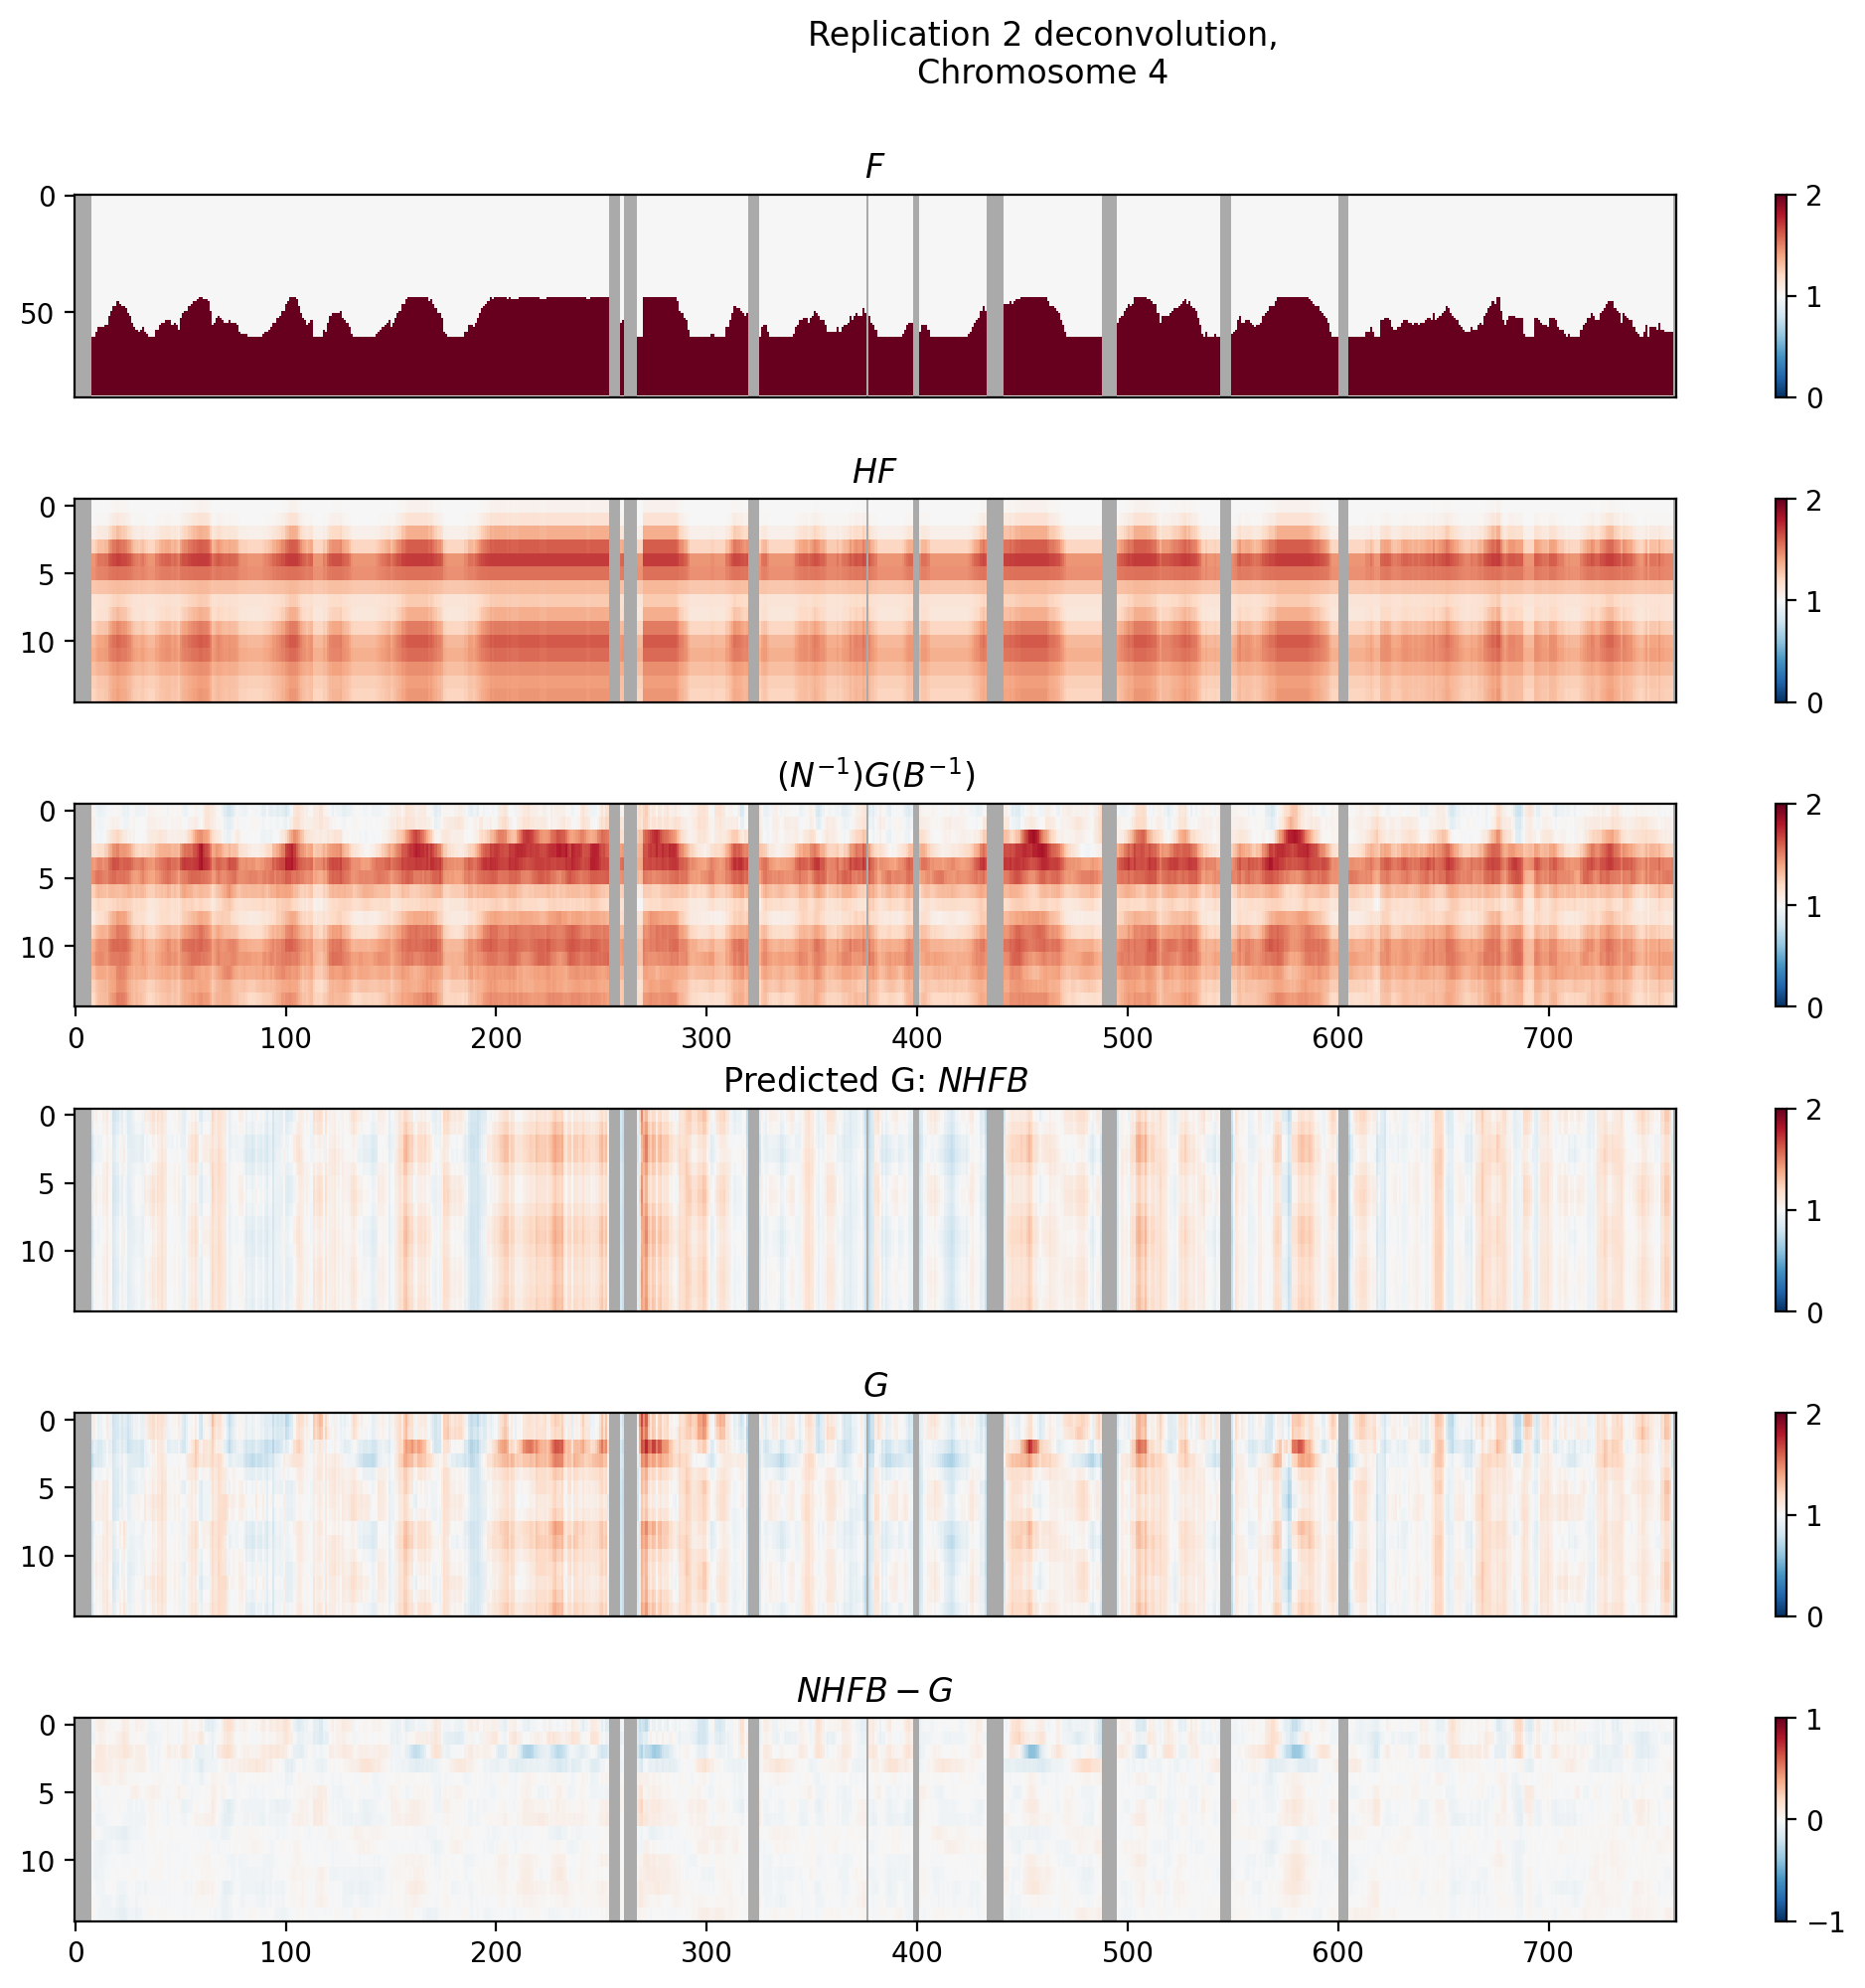

In [11]:
real_deconv2.plot_heatmaps()

In [12]:
optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv2.N,
    F=real_deconv2.F,
    B=real_deconv2.B,
    G=real_deconv2.G
)


In [13]:
from src.timer import Timer
from src.single_G1_config import calcH

timer = Timer()

num_epochs = 1000
num_iterations_N_B = 5
update_params_df = pd.DataFrame()

N = real_deconv2.N
B = real_deconv2.B

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv2.N,
    F=real_deconv2.F,
    B=real_deconv2.B,
    G=real_deconv2.G
)

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv2.H = optimizer.current_H
        
    real_deconv2.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv2.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv2.N
    optimizer.B = real_deconv2.B
    optimizer.F = real_deconv2.F
    
    N = real_deconv2.N
    B = real_deconv2.B

    print(update_params_df.iloc[-1])


Epoch:  0
Optimization [1]: Current loss: 0.0022407398606555
Optimization [101]: Current loss: 0.002198701575569247
Optimization [201]: Current loss: 0.0021976682216556078
Optimization terminated successfully.
         Current function value: 0.002198
         Iterations: 138
         Function evaluations: 217
Iteration 0
0/706 - 00:00:57.111
100/706 - 00:00:57.155
200/706 - 00:00:57.211
300/706 - 00:00:57.252
400/706 - 00:00:57.295
500/706 - 00:00:57.335
600/706 - 00:00:57.375
700/706 - 00:00:57.415
Iteration completed 00:00:58.414, rn=0.002163026835861224
Iteration 1
0/706 - 00:00:58.415
100/706 - 00:00:58.455
200/706 - 00:00:58.496
300/706 - 00:00:58.536
400/706 - 00:00:58.577
500/706 - 00:00:58.617
600/706 - 00:00:58.658
700/706 - 00:00:58.699
Iteration completed 00:00:59.709, rn=0.002086984779673463
Iteration 2
0/706 - 00:00:59.713
100/706 - 00:00:59.754
200/706 - 00:00:59.794
300/706 - 00:00:59.835
400/706 - 00:00:59.875
500/706 - 00:00:59.916
600/706 - 00:00:59.961
700/706 - 00:

400/706 - 00:06:27.348
500/706 - 00:06:27.425
600/706 - 00:06:27.503
700/706 - 00:06:27.582
Iteration completed 00:06:28.388, rn=0.001784155010384842
Iteration 2
0/706 - 00:06:28.389
100/706 - 00:06:28.468
200/706 - 00:06:28.541
300/706 - 00:06:28.618
400/706 - 00:06:28.691
500/706 - 00:06:28.772
600/706 - 00:06:28.853
700/706 - 00:06:28.931
Iteration completed 00:06:29.915, rn=0.0017837791396924894
Iteration 3
0/706 - 00:06:29.917
100/706 - 00:06:29.990
200/706 - 00:06:30.066
300/706 - 00:06:30.140
400/706 - 00:06:30.217
500/706 - 00:06:30.313
600/706 - 00:06:30.389
700/706 - 00:06:30.474
Iteration completed 00:06:31.595, rn=0.0017833321536030618
Iteration 4
0/706 - 00:06:31.597
100/706 - 00:06:31.671
200/706 - 00:06:31.748
300/706 - 00:06:31.822
400/706 - 00:06:31.897
500/706 - 00:06:31.972
600/706 - 00:06:32.047
700/706 - 00:06:32.122
Iteration completed 00:06:33.231, rn=0.0017829650988053607
00:06:33.232
mu0            1.653385
lambda        60.000000
delta         12.879588
sigma0

300/706 - 00:11:45.364
400/706 - 00:11:45.434
500/706 - 00:11:45.506
600/706 - 00:11:45.579
700/706 - 00:11:45.649
Iteration completed 00:11:46.516, rn=0.001686924887941813
00:11:46.517
mu0            2.911812
lambda        60.000000
delta         12.718844
sigma0         6.540833
sigmav         0.158978
gamma1         0.360527
gamma2         0.920189
halted         0.165704
opt_H_loss     0.001694
F_rn           0.001687
Name: 8, dtype: float64
Epoch:  9
Optimization [1]: Current loss: 0.0016869248879418125
Optimization [101]: Current loss: 0.001678803473693204
Optimization [201]: Current loss: 0.0016784637218218094
Optimization terminated successfully.
         Current function value: 0.001678
         Iterations: 162
         Function evaluations: 253
Iteration 0
0/706 - 00:12:52.239
100/706 - 00:12:52.360
200/706 - 00:12:52.430
300/706 - 00:12:52.500
400/706 - 00:12:52.572
500/706 - 00:12:52.643
600/706 - 00:12:52.715
700/706 - 00:12:52.791
Iteration completed 00:12:53.209, rn=0.00

100/706 - 00:17:38.981
200/706 - 00:17:39.063
300/706 - 00:17:39.145
400/706 - 00:17:39.226
500/706 - 00:17:39.308
600/706 - 00:17:39.391
700/706 - 00:17:39.476
Iteration completed 00:17:39.810, rn=0.0016340825987491115
Iteration 1
0/706 - 00:17:39.812
100/706 - 00:17:39.891
200/706 - 00:17:39.990
300/706 - 00:17:40.072
400/706 - 00:17:40.154
500/706 - 00:17:40.235
600/706 - 00:17:40.317
700/706 - 00:17:40.398
Iteration completed 00:17:40.876, rn=0.0016331199000507246
Iteration 2
0/706 - 00:17:40.877
100/706 - 00:17:40.957
200/706 - 00:17:41.037
300/706 - 00:17:41.117
400/706 - 00:17:41.199
500/706 - 00:17:41.281
600/706 - 00:17:41.363
700/706 - 00:17:41.443
Iteration completed 00:17:41.675, rn=0.0016328239949325177
Iteration 3
0/706 - 00:17:41.676
100/706 - 00:17:41.755
200/706 - 00:17:41.835
300/706 - 00:17:41.914
400/706 - 00:17:41.994
500/706 - 00:17:42.075
600/706 - 00:17:42.156
700/706 - 00:17:42.235
Iteration completed 00:17:42.519, rn=0.0016328171684791674
Iteration 4
0/706 - 0

500/706 - 00:23:18.252
600/706 - 00:23:18.331
700/706 - 00:23:18.409
Iteration completed 00:23:19.092, rn=0.0016103613130095775
Iteration 3
0/706 - 00:23:19.096
100/706 - 00:23:19.200
200/706 - 00:23:19.286
300/706 - 00:23:19.364
400/706 - 00:23:19.445
500/706 - 00:23:19.524
600/706 - 00:23:19.604
700/706 - 00:23:19.682
Iteration completed 00:23:20.445, rn=0.0016103613116374921
Iteration 4
0/706 - 00:23:20.446
100/706 - 00:23:20.525
200/706 - 00:23:20.604
300/706 - 00:23:20.684
400/706 - 00:23:20.762
500/706 - 00:23:20.840
600/706 - 00:23:20.920
700/706 - 00:23:21.000
Iteration completed 00:23:22.033, rn=0.0016103613116374299
00:23:22.033
mu0            4.958953
lambda        60.000000
delta         11.024914
sigma0         6.528974
sigmav         0.153519
gamma1         0.405330
gamma2         1.000000
halted         0.015731
opt_H_loss     0.001610
F_rn           0.001610
Name: 17, dtype: float64
Epoch:  18
Optimization [1]: Current loss: 0.0016103613116374297
Optimization [101]: Cur

...

100/706 - 09:21:20.245
200/706 - 09:21:20.324
300/706 - 09:21:20.403
400/706 - 09:21:20.481
500/706 - 09:21:20.559
600/706 - 09:21:20.638
700/706 - 09:21:20.716
Iteration completed 09:21:21.386, rn=0.0015236805432846407
Iteration 3
0/706 - 09:21:21.388
100/706 - 09:21:21.466
200/706 - 09:21:21.544
300/706 - 09:21:21.623
400/706 - 09:21:21.701
500/706 - 09:21:21.781
600/706 - 09:21:21.864
700/706 - 09:21:21.943
Iteration completed 09:21:22.329, rn=0.0015236805432829153
Iteration 4
0/706 - 09:21:22.330
100/706 - 09:21:22.408
200/706 - 09:21:22.487
300/706 - 09:21:22.566
400/706 - 09:21:22.644
500/706 - 09:21:22.723
600/706 - 09:21:22.801
700/706 - 09:21:22.880
Iteration completed 09:21:23.227, rn=0.0015236805432829147
09:21:23.227
mu0           20.012572
lambda        60.000000
delta          9.156930
sigma0         3.923146
sigmav         0.114938
gamma1         0.662741
gamma2         1.000000
halted         0.000001
opt_H_loss     0.001524
F_rn           0.001524
Name: 980, dtype: flo

100/706 - 09:23:33.061
200/706 - 09:23:33.139
300/706 - 09:23:33.218
400/706 - 09:23:33.295
500/706 - 09:23:33.374
600/706 - 09:23:33.452
700/706 - 09:23:33.531
Iteration completed 09:23:33.938, rn=0.00152369653345444
Iteration 1
0/706 - 09:23:33.939
100/706 - 09:23:34.017
200/706 - 09:23:34.097
300/706 - 09:23:34.177
400/706 - 09:23:34.255
500/706 - 09:23:34.333
600/706 - 09:23:34.411
700/706 - 09:23:34.490
Iteration completed 09:23:35.016, rn=0.0015237000585553546
Iteration 2
0/706 - 09:23:35.017
100/706 - 09:23:35.096
200/706 - 09:23:35.174
300/706 - 09:23:35.253
400/706 - 09:23:35.332
500/706 - 09:23:35.410
600/706 - 09:23:35.489
700/706 - 09:23:35.568
Iteration completed 09:23:36.101, rn=0.0015237002180932592
Iteration 3
0/706 - 09:23:36.103
100/706 - 09:23:36.181
200/706 - 09:23:36.259
300/706 - 09:23:36.337
400/706 - 09:23:36.415
500/706 - 09:23:36.493
600/706 - 09:23:36.572
700/706 - 09:23:36.652
Iteration completed 09:23:36.902, rn=0.0015237002180919104
Iteration 4
0/706 - 09:

mu0           20.015296
lambda        60.000000
delta          9.153491
sigma0         3.923365
sigmav         0.114949
gamma1         0.662779
gamma2         1.000000
halted         0.000002
opt_H_loss     0.001524
F_rn           0.001524
Name: 989, dtype: float64
Epoch:  990
Optimization [1]: Current loss: 0.0015237407094276937
Optimization terminated successfully.
         Current function value: 0.001524
         Iterations: 45
         Function evaluations: 88
Iteration 0
0/706 - 09:25:46.470
100/706 - 09:25:46.560
200/706 - 09:25:46.667
300/706 - 09:25:46.750
400/706 - 09:25:46.830
500/706 - 09:25:46.915
600/706 - 09:25:47.006
700/706 - 09:25:47.091
Iteration completed 09:25:47.245, rn=0.001523743199827704
Iteration 1
0/706 - 09:25:47.247
100/706 - 09:25:47.336
200/706 - 09:25:47.420
300/706 - 09:25:47.499
400/706 - 09:25:47.584
500/706 - 09:25:47.665
600/706 - 09:25:47.744
700/706 - 09:25:47.823
Iteration completed 09:25:48.596, rn=0.001523692470349942
Iteration 2
0/706 - 09:25:

100/706 - 09:27:48.406
200/706 - 09:27:48.485
300/706 - 09:27:48.563
400/706 - 09:27:48.650
500/706 - 09:27:48.737
600/706 - 09:27:48.839
700/706 - 09:27:48.918
Iteration completed 09:27:49.747, rn=0.0015237300721138297
Iteration 4
0/706 - 09:27:49.748
100/706 - 09:27:49.833
200/706 - 09:27:49.916
300/706 - 09:27:49.994
400/706 - 09:27:50.077
500/706 - 09:27:50.155
600/706 - 09:27:50.234
700/706 - 09:27:50.314
Iteration completed 09:27:51.069, rn=0.0015237300721138397
09:27:51.069
mu0           20.019036
lambda        60.000000
delta          9.150097
sigma0         3.919161
sigmav         0.114961
gamma1         0.662853
gamma2         1.000000
halted         0.000002
opt_H_loss     0.001524
F_rn           0.001524
Name: 994, dtype: float64
Epoch:  995
Optimization [1]: Current loss: 0.0015237300721138403
Optimization [101]: Current loss: 0.0015237305559637915
Optimization terminated successfully.
         Current function value: 0.001524
         Iterations: 54
         Function eval

600/706 - 09:30:22.816
700/706 - 09:30:22.897
Iteration completed 09:30:23.763, rn=0.0015238217484714383
Iteration 1
0/706 - 09:30:23.766
100/706 - 09:30:23.910
200/706 - 09:30:24.075
300/706 - 09:30:24.155
400/706 - 09:30:24.235
500/706 - 09:30:24.323
600/706 - 09:30:24.401
700/706 - 09:30:24.479
Iteration completed 09:30:25.832, rn=0.001523813355144479
Iteration 2
0/706 - 09:30:25.835
100/706 - 09:30:25.940
200/706 - 09:30:26.022
300/706 - 09:30:26.105
400/706 - 09:30:26.188
500/706 - 09:30:26.267
600/706 - 09:30:26.346
700/706 - 09:30:26.423
Iteration completed 09:30:27.517, rn=0.0015238133273944943
Iteration 3
0/706 - 09:30:27.522
100/706 - 09:30:27.606
200/706 - 09:30:27.684
300/706 - 09:30:27.762
400/706 - 09:30:27.841
500/706 - 09:30:27.919
600/706 - 09:30:27.998
700/706 - 09:30:28.077
Iteration completed 09:30:29.115, rn=0.001523813327395842
Iteration 4
0/706 - 09:30:29.116
100/706 - 09:30:29.194
200/706 - 09:30:29.273
300/706 - 09:30:29.352
400/706 - 09:30:29.431
500/706 - 09:

In [14]:
config.params_dic#get_Hpositions_for_phase('S')

{'mu0': 20.023849228718376,
 'delta': 9.154396119904217,
 'sigma0': 3.9188055191038096,
 'sigmav': 0.11491985222250826,
 'lambda': 60.000000000000114,
 'gamma1': 0.6629525211716354,
 'gamma2': 1.0,
 'halted': 1.798428892436295e-06,
 'alpha': 20}

Text(0.5, 0.98, 'Cell cycle parameter updates, 1000 epochs')

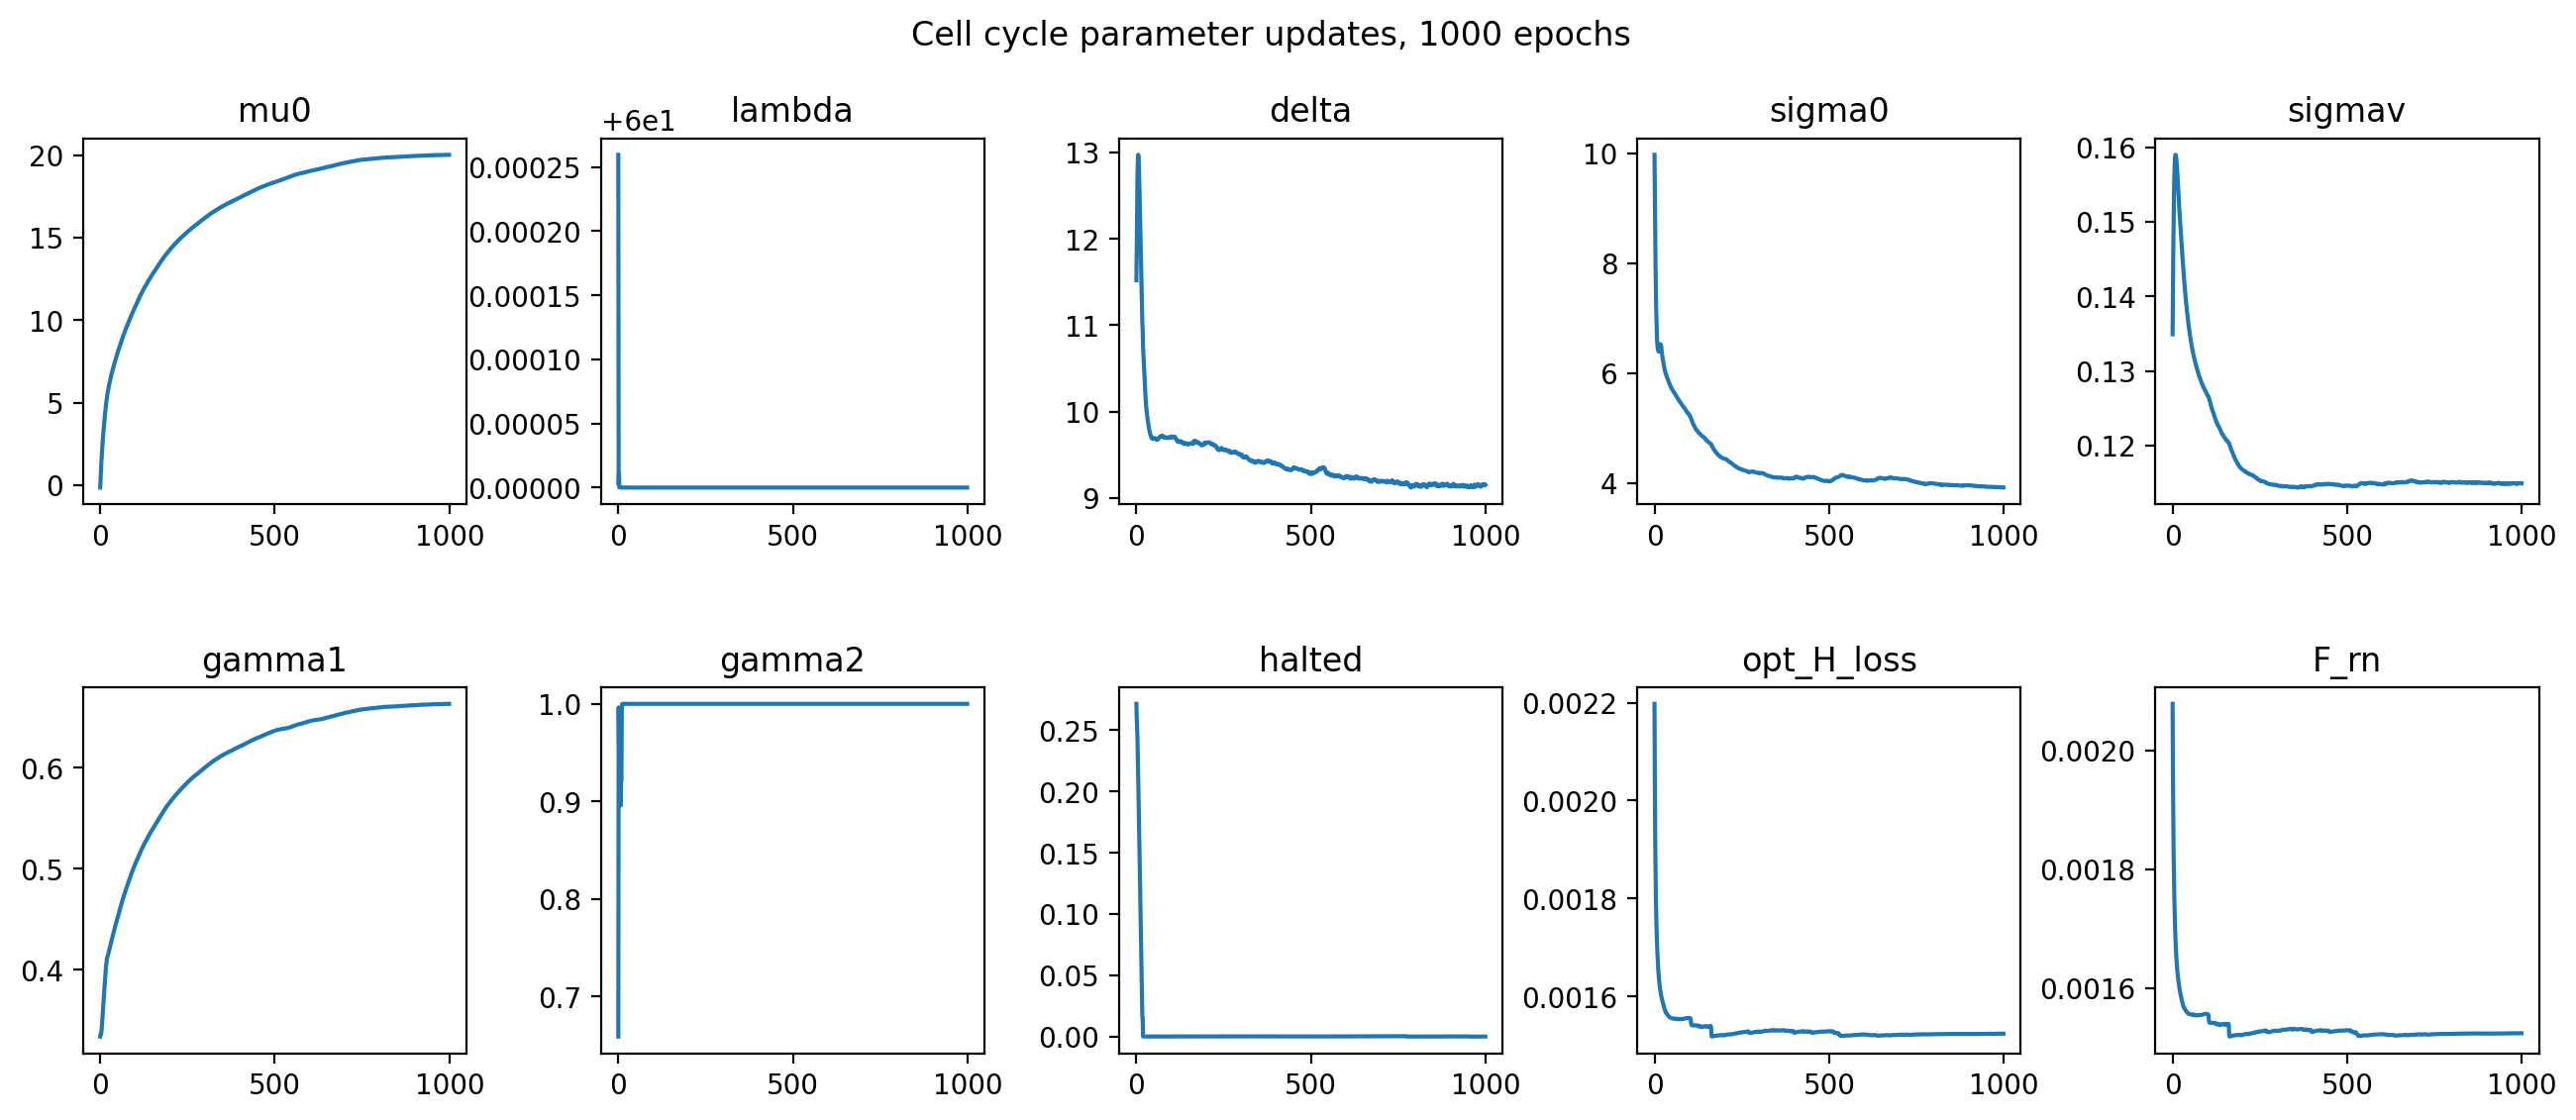

In [15]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

In [20]:
real_deconv2.config.get_s_g2m_indices()

(array([44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
        61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
        78, 79, 80, 81, 82, 83, 84, 85]),
 array([], dtype=int64))

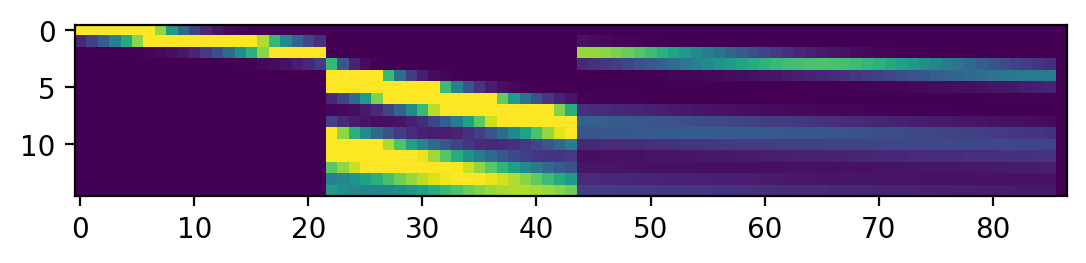

In [16]:
plt.imshow(real_deconv2.H, vmax=0.05)

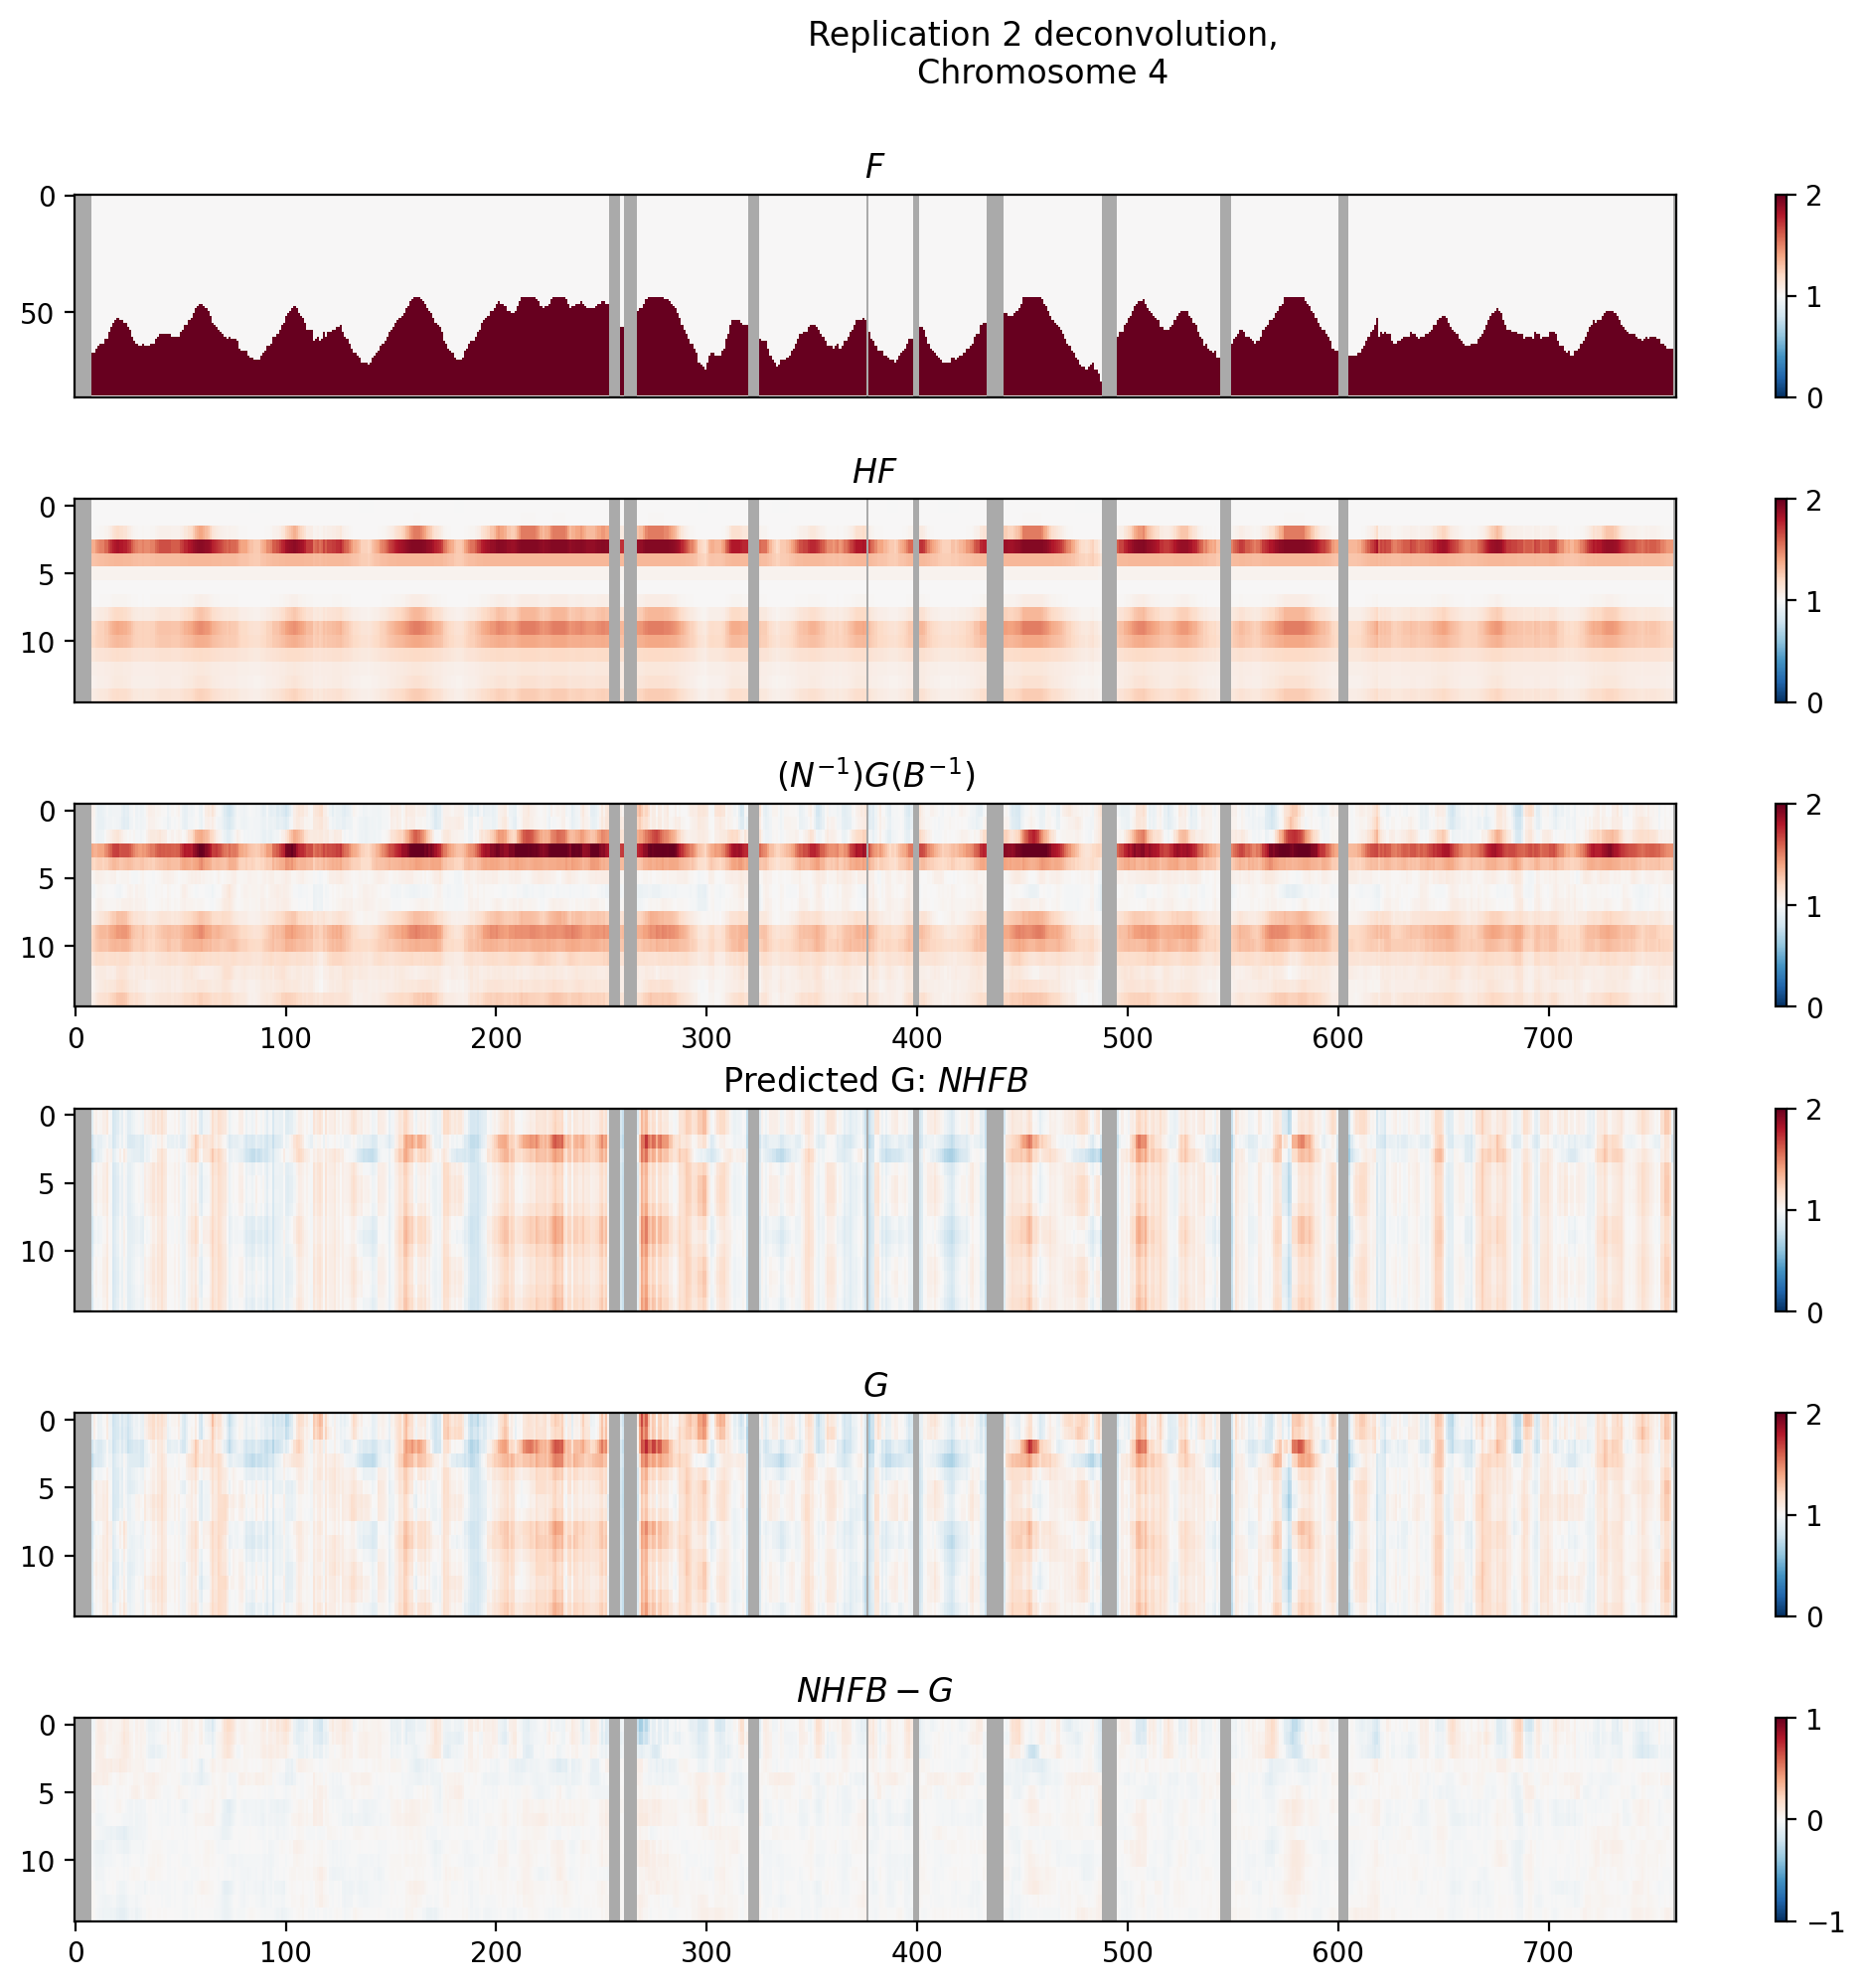

In [17]:
real_deconv2.plot_heatmaps()

7.222445974893539

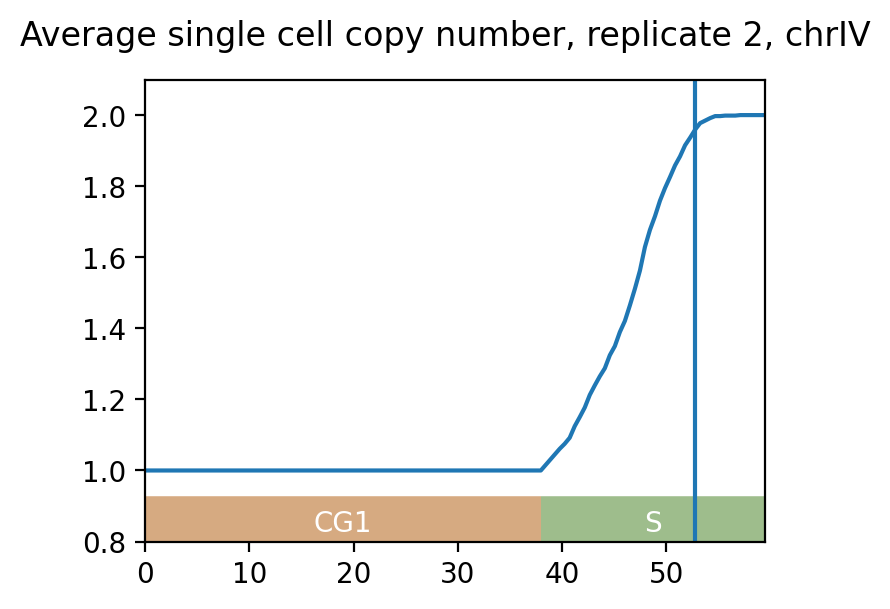

In [32]:
from src.chromatin_model import draw_phase_label_annotations

fig = plt.figure(figsize=(4, 3))
t_indices = config.get_Hpositions_for_branch('t')
t_tps = config.get_timepoints_for_branch('t')
plt.plot(t_tps, real_deconv2.F.mean(axis=1)[t_indices])
draw_phase_label_annotations(plt.gca(), config, flip=True, annotations_x=0.85)
plt.xlim(t_tps[0], t_tps[-1])
plt.ylim(0.8, 2.1)
plt.suptitle("Average single cell copy number, replicate 2, chrIV")

# Plot when 95% of the genome has been replicated
x, y = t_tps, real_deconv2.F.mean(axis=1)[t_indices]
g2m_start = t_tps[y > 1.95][0]
plt.axvline(g2m_start)
config.params_dic['lambda'] - g2m_start

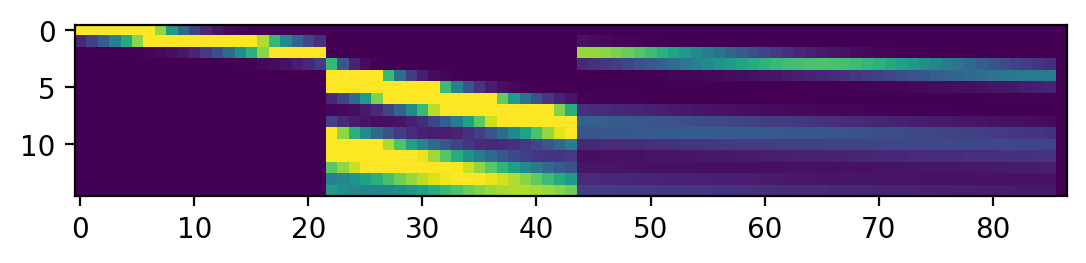

In [18]:
plt.imshow(config.H, vmax=0.05)

In [19]:
config.params_dic

{'mu0': 20.023849228718376,
 'delta': 9.154396119904217,
 'sigma0': 3.9188055191038096,
 'sigmav': 0.11491985222250826,
 'lambda': 60.000000000000114,
 'gamma1': 0.6629525211716354,
 'gamma2': 1.0,
 'halted': 1.798428892436295e-06,
 'alpha': 20}